# ResNet-18 (Naive — Frozen Backbone)

**Objective**: Establish a baseline for ResNet-18 on the HAM10000 dataset using a naive approach. This iteration trains only the final fully connected layer (linear probing) to see how well the pretrained ImageNet features transfer to dermatological images without any fine-tuning.

**Architecture Changes**:
| Component | Previous iteration | This iteration |
|---|---|---|
| Architecture | N/A | ResNet-18 |
| Unfrozen layers | N/A | None (FC only) |
| Trainable params | N/A | ~513 |
| Weight decay | N/A | 0 |
| L1 lambda | N/A | 0 |
| L2 lambda | N/A | 0 |
| Dropout | N/A | 0 |
| Epochs | N/A | 20 |

**Hypothesis**: As a baseline, linear probing should achieve reasonable AUC (>0.80) due to the general feature extraction capabilities of ResNet-18, but recall and F2 will likely be low without backbone adaptation or class weighting optimization beyond the BCE `pos_weight`.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_resnet(num_classes=1, freeze_backbone=True).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 513 / 11,177,025
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet_naive_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 1.1763, Bal Acc: 0.6038, Recall: 0.6169, F2: 0.3886, AUC: 0.6446
  Val   | Loss: 1.1956, Bal Acc: 0.6075, Recall: 0.9364, F2: 0.4501, AUC: 0.7129
  -> Saved best model (val AUC: 0.7129)


Epoch [2/20]
  Train | Loss: 1.0954, Bal Acc: 0.6674, Recall: 0.6670, F2: 0.4531, AUC: 0.7355
  Val   | Loss: 1.1818, Bal Acc: 0.6142, Recall: 0.9746, F2: 0.4585, AUC: 0.7726
  -> Saved best model (val AUC: 0.7726)


Epoch [3/20]
  Train | Loss: 1.0382, Bal Acc: 0.7075, Recall: 0.7355, F2: 0.5013, AUC: 0.7753
  Val   | Loss: 1.0874, Bal Acc: 0.6919, Recall: 0.9492, F2: 0.5140, AUC: 0.7880
  -> Saved best model (val AUC: 0.7880)


Epoch [4/20]
  Train | Loss: 1.0066, Bal Acc: 0.7127, Recall: 0.7320, F2: 0.5070, AUC: 0.7893
  Val   | Loss: 1.0853, Bal Acc: 0.6908, Recall: 0.9661, F2: 0.5142, AUC: 0.8004
  -> Saved best model (val AUC: 0.8004)


Epoch [5/20]
  Train | Loss: 0.9890, Bal Acc: 0.7211, Recall: 0.7514, F2: 0.5175, AUC: 0.7940
  Val   | Loss: 1.0662, Bal Acc: 0.7088, Recall: 0.9746, F2: 0.5300, AUC: 0.8035
  -> Saved best model (val AUC: 0.8035)


...

Epoch [16/20]
  Train | Loss: 0.9228, Bal Acc: 0.7380, Recall: 0.7640, F2: 0.5380, AUC: 0.8167
  Val   | Loss: 0.9623, Bal Acc: 0.7395, Recall: 0.9364, F2: 0.5572, AUC: 0.8265
  -> Saved best model (val AUC: 0.8265)


Epoch [17/20]
  Train | Loss: 0.8982, Bal Acc: 0.7411, Recall: 0.7742, F2: 0.5420, AUC: 0.8273
  Val   | Loss: 0.9469, Bal Acc: 0.7296, Recall: 0.8983, F2: 0.5461, AUC: 0.8285
  -> Saved best model (val AUC: 0.8285)


Epoch [18/20]
  Train | Loss: 0.9140, Bal Acc: 0.7363, Recall: 0.7617, F2: 0.5359, AUC: 0.8201
  Val   | Loss: 0.9686, Bal Acc: 0.7382, Recall: 0.9407, F2: 0.5561, AUC: 0.8287
  -> Saved best model (val AUC: 0.8287)


Epoch [19/20]
  Train | Loss: 0.9082, Bal Acc: 0.7388, Recall: 0.7754, F2: 0.5391, AUC: 0.8216
  Val   | Loss: 0.9303, Bal Acc: 0.7387, Recall: 0.8941, F2: 0.5553, AUC: 0.8298
  -> Saved best model (val AUC: 0.8298)


Epoch [20/20]
  Train | Loss: 0.9149, Bal Acc: 0.7318, Recall: 0.7548, F2: 0.5303, AUC: 0.8181
  Val   | Loss: 0.9627, Bal Acc: 0.7444, Recall: 0.9492, F2: 0.5625, AUC: 0.8313
  -> Saved best model (val AUC: 0.8313)


## Plot Train and Validation Curves

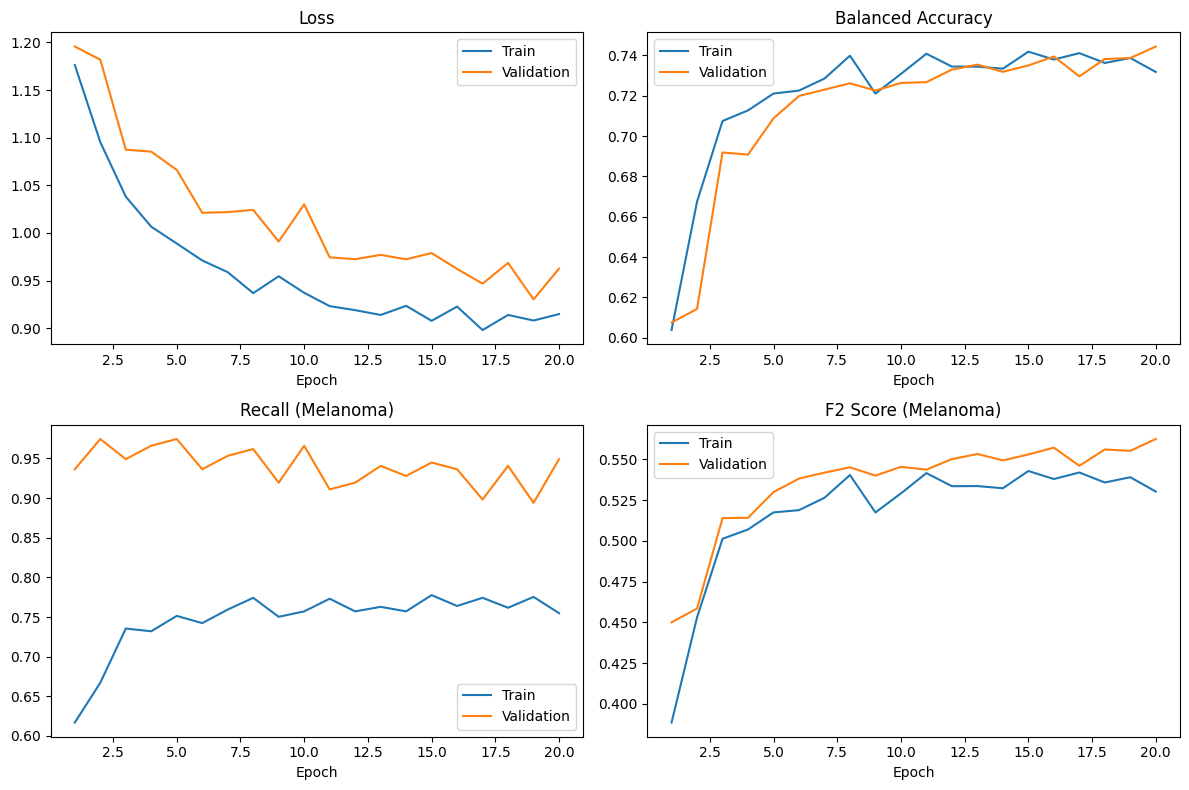

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet_naive_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.66 | Val F2: 0.5701


## Test Set Evaluation

Threshold:          0.66
AUC-ROC:            0.8429
Balanced Accuracy:  0.7635
F2 Score:           0.5757

              precision    recall  f1-score   support

Non-Melanoma     0.9730    0.6731    0.7958      1340
    Melanoma     0.2500    0.8538    0.3868       171

    accuracy                         0.6936      1511
   macro avg     0.6115    0.7635    0.5913      1511
weighted avg     0.8912    0.6936    0.7495      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


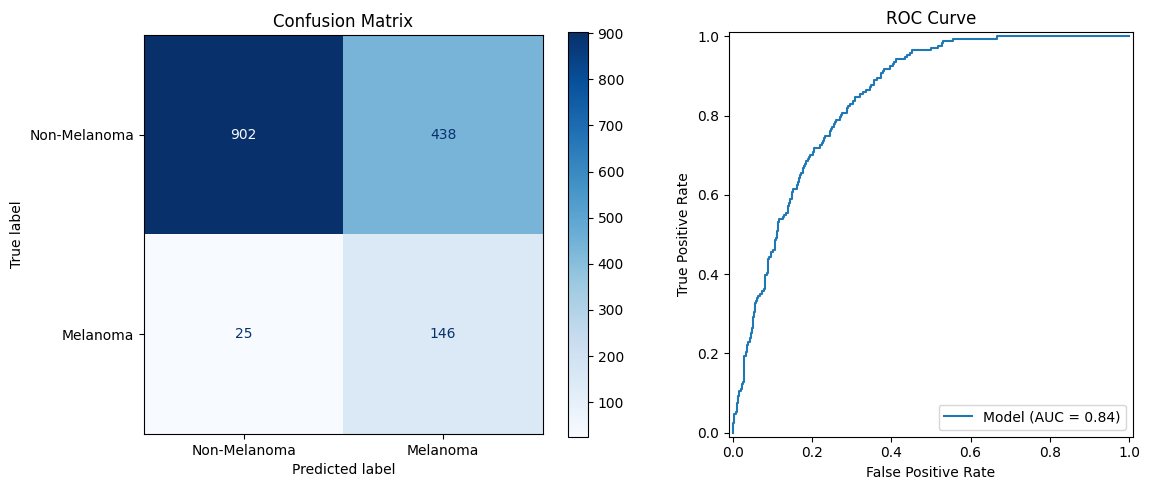

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)